In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
import os
import sys
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the 3d projection
import plotly.graph_objects as go

PDM_DIR = os.environ.get('PDM_DIR', '../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import (load_mem_results_scores_grid,
                                              discover_offset_prefix_points)
from attn_bench.plotting.prefix_suffix import (show_plotly, plot_offset_prefix_grid_3d,
                                               plot_offset_prefix_grid_2d)


# Plotting experiments

Scratch notebook for trying out new ways to visualize the offset x prefix x suffix x
repetition x model space (see the SWA-variants discussion in `swa_variants.ipynb`) --
new plot layouts, dimensionality choices, whatever. Code here is exploratory and doesn't
need to be clean; once something earns its keep, promote it into
`attn_bench/plotting/utils.py` and a proper analysis notebook instead of leaving it here.


## Function definitions

Every plotting/loading function used below, defined once here -- sections further down only
load data and call these. Keeps the calling cells short and avoids the out-of-order-execution
breakage that comes from a def buried mid-notebook (a later section calling it before its own
cell has run in this session).


In [ ]:
def plot_offset_prefix_reps(grid, model, reps, suffix, metric='Rouge-L', ncols=5, elev=25, azim=-60):
    """One 3D scatter subplot per repetition: x=offset, y=prefix, z=metric."""
    points = []
    for (offset, prefix, suf), per_model in grid.items():
        if suf != suffix or model not in per_model:
            continue
        r = per_model[model]
        expr = r.expr[0]
        means = {}
        for rep in reps:
            try:
                means[rep] = r.get_all_metrics(expr, rep, offset, prefix, suf)[metric].mean
            except KeyError:
                pass
        points.append((offset, prefix, means))

    n = len(reps)
    nrows = math.ceil(n / ncols)
    fig = plt.figure(figsize=(4.5 * ncols, 4 * nrows))
    sc = None
    for i, rep in enumerate(reps):
        ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')
        xs, ys, zs = [], [], []
        for offset, prefix, means in points:
            if rep in means:
                xs.append(offset); ys.append(prefix); zs.append(means[rep])
        sc = ax.scatter(xs, ys, zs, c=zs, cmap='YlOrRd', vmin=0, vmax=1, s=40, edgecolor='k', linewidth=0.3)
        ax.set_xlabel('offset', fontsize=8)
        ax.set_ylabel('prefix', fontsize=8)
        ax.set_zlabel(metric, fontsize=8)
        ax.set_zlim(0, 1)
        ax.set_title(f'rep={rep}', fontsize=10, weight='bold')
        ax.view_init(elev=elev, azim=azim)
    fig.suptitle(f'{model}: {metric} vs (offset, prefix), suffix={suffix}', fontsize=14, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    fig.colorbar(sc, ax=fig.axes, shrink=0.4, pad=0.02, label=metric)
    plt.show()


def plot_offset_prefix_surface(grid, model, rep, suffix, metric='Rouge-L', diagonal_starts=None,
                               cmap='turbo', floor=-0.2, elev=28, azim=-60):
    """Triangulated 3D surface + floor-projected contour shadow + optional thick lines along
    fixed offset+prefix=S diagonals."""
    xs, ys, zs = [], [], []
    for (offset, prefix, suf), per_model in grid.items():
        if suf != suffix or model not in per_model:
            continue
        r = per_model[model]
        expr = r.expr[0]
        try:
            z = r.get_all_metrics(expr, rep, offset, prefix, suf)[metric].mean
        except KeyError:
            continue
        xs.append(offset); ys.append(prefix); zs.append(z)

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_trisurf(xs, ys, zs, cmap=cmap, vmin=0, vmax=1, edgecolor='k',
                           linewidth=0.3, alpha=0.95, antialiased=True)
    ax.tricontourf(xs, ys, zs, zdir='z', offset=floor, cmap=cmap, vmin=0, vmax=1,
                   alpha=0.6, levels=12)

    for S in (diagonal_starts or []):
        diag = sorted((o, p, z) for o, p, z in zip(xs, ys, zs) if o + p == S)
        if len(diag) < 2:
            print(f'diagonal_starts={S}: fewer than 2 points on this grid, skipped')
            continue
        do, dp, dz = zip(*diag)
        ax.plot(do, dp, dz, color='black', linewidth=3, marker='o', markersize=4, zorder=10,
               label=f'S={S}')

    ax.set_xlabel('offset')
    ax.set_ylabel('prefix')
    ax.set_zlabel(metric)
    ax.set_zlim(floor, 1)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'{model}: {metric} at rep={rep}, suffix={suffix}', fontsize=13, weight='bold')
    if diagonal_starts:
        ax.legend(fontsize=9)
    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.08, label=metric)
    plt.tight_layout()
    plt.show()


def plot_cloud_and_surface(model, rep, suffix, backends=('hf', 'megatron'), metric='Rouge-L',
                           cmap='turbo', floor=-0.2, elev=28, azim=-60, points=None):
    """points: optional explicit [(offset, prefix), ...] instead of every point discovered
    on disk."""
    if points is None:
        points = discover_offset_prefix_points(model, suffix, backend=backends)
    offsets = sorted({o for o, p in points})
    prefixes = sorted({p for o, p in points})
    grid = load_mem_results_scores_grid(offsets, prefixes, [suffix], models=[model],
                                        results_base=model_registry.MEM_RESULTS_DIR, backend=list(backends))
    xs, ys, zs = [], [], []
    for offset, prefix in points:
        key = (offset, prefix, suffix)
        if key not in grid or model not in grid[key]:
            continue
        r = grid[key][model]
        expr = r.expr[0]
        try:
            z = r.get_all_metrics(expr, rep, offset, prefix, suffix)[metric].mean
        except KeyError:
            continue
        xs.append(offset); ys.append(prefix); zs.append(z)

    fig = plt.figure(figsize=(15, 7))
    ax1 = fig.add_subplot(121, projection='3d')
    sc = ax1.scatter(xs, ys, zs, c=zs, cmap=cmap, vmin=0, vmax=1, s=35, edgecolor='k', linewidth=0.3)
    ax1.set_xlabel('offset'); ax1.set_ylabel('prefix'); ax1.set_zlabel(metric)
    ax1.set_zlim(0, 1)
    ax1.set_title('cloud', fontsize=11)
    ax1.view_init(elev=elev, azim=azim)

    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_trisurf(xs, ys, zs, cmap=cmap, vmin=0, vmax=1, edgecolor='k', linewidth=0.3, alpha=0.95)
    ax2.tricontourf(xs, ys, zs, zdir='z', offset=floor, cmap=cmap, vmin=0, vmax=1, alpha=0.6, levels=12)
    ax2.set_xlabel('offset'); ax2.set_ylabel('prefix'); ax2.set_zlabel(metric)
    ax2.set_zlim(floor, 1)
    ax2.set_title('surface', fontsize=11)
    ax2.view_init(elev=elev, azim=azim)

    fig.suptitle(f'{model}: {metric} at rep={rep}, suffix={suffix}  ({len(xs)} points)', fontsize=13, weight='bold')
    fig.colorbar(sc, ax=[ax1, ax2], shrink=0.4, pad=0.05, label=metric)
    plt.show()


def _bar_mesh(x, y, z, dx, dy):
    """8 vertices + 12 triangles for one axis-aligned cuboid from z=0 to z."""
    x0, x1, y0, y1 = x - dx / 2, x + dx / 2, y - dy / 2, y + dy / 2
    xv = [x0, x1, x1, x0, x0, x1, x1, x0]
    yv = [y0, y0, y1, y1, y0, y0, y1, y1]
    zv = [0, 0, 0, 0, z, z, z, z]
    i = [0, 0, 4, 4, 0, 0, 3, 3, 0, 0, 1, 1]
    j = [1, 2, 5, 6, 1, 5, 2, 6, 3, 7, 2, 6]
    k = [2, 3, 6, 7, 5, 4, 6, 7, 7, 4, 6, 5]
    return xv, yv, zv, i, j, k


def plot_cloud_bars_plotly(model, rep, suffix, backends=('hf', 'megatron'), metric='Rouge-L',
                           bar_frac=0.02, cmap='Turbo', points=None):
    """One bar per real point, no interpolation. bar_frac sizes bars off the axis range, not
    the nearest-neighbor gap (a sparse, irregular point set makes gap-sizing produce
    invisible needles)."""
    if points is None:
        points = discover_offset_prefix_points(model, suffix, backend=backends)
    offsets = sorted({o for o, p in points})
    prefixes = sorted({p for o, p in points})
    grid_data = load_mem_results_scores_grid(offsets, prefixes, [suffix], models=[model],
                                             results_base=model_registry.MEM_RESULTS_DIR, backend=list(backends))
    xs, ys, zs = [], [], []
    for offset, prefix in points:
        key = (offset, prefix, suffix)
        if key not in grid_data or model not in grid_data[key]:
            continue
        r = grid_data[key][model]
        expr = r.expr[0]
        try:
            z = r.get_all_metrics(expr, rep, offset, prefix, suffix)[metric].mean
        except KeyError:
            continue
        xs.append(offset); ys.append(prefix); zs.append(z)
    xs, ys, zs = np.array(xs, float), np.array(ys, float), np.array(zs, float)

    dx = (xs.max() - xs.min()) * bar_frac
    dy = (ys.max() - ys.min()) * bar_frac

    fig = go.Figure()
    for idx, (x, y, z) in enumerate(zip(xs, ys, zs)):
        xv, yv, zv, i, j, k = _bar_mesh(x, y, z, dx, dy)
        fig.add_trace(go.Mesh3d(
            x=xv, y=yv, z=zv, i=i, j=j, k=k,
            intensity=[z] * 8, colorscale=cmap, cmin=0, cmax=1, showscale=bool(idx == 0),
            opacity=1.0, flatshading=True,
        ))
    fig.update_layout(
        title=f'{model}: {metric} at rep={rep}, suffix={suffix} ({len(xs)} points, bars)',
        scene=dict(xaxis_title='offset', yaxis_title='prefix', zaxis_title=metric, zaxis_range=[0, 1]),
        width=1000, height=800, showlegend=False,
    )
    show_plotly(fig, iframe=True)


def plot_offset_prefix_panel_2d(model, rep, suffix, backends=('hf', 'megatron'), metric='Rouge-L',
                                cmap='turbo', levels=20, ax=None, points=None):
    """x=offset, y=prefix, matplotlib tricontourf + scatter."""
    if points is None:
        points = discover_offset_prefix_points(model, suffix, backend=backends)
    offsets = sorted({o for o, p in points})
    prefixes = sorted({p for o, p in points})
    grid_data = load_mem_results_scores_grid(offsets, prefixes, [suffix], models=[model],
                                             results_base=model_registry.MEM_RESULTS_DIR, backend=list(backends))
    xs, ys, zs = [], [], []
    for offset, prefix in points:
        key = (offset, prefix, suffix)
        if key not in grid_data or model not in grid_data[key]:
            continue
        r = grid_data[key][model]
        expr = r.expr[0]
        try:
            z = r.get_all_metrics(expr, rep, offset, prefix, suffix)[metric].mean
        except KeyError:
            continue
        xs.append(offset); ys.append(prefix); zs.append(z)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))
    cf = ax.tricontourf(xs, ys, zs, levels=levels, cmap=cmap, vmin=0, vmax=1)
    ax.scatter(xs, ys, c=zs, cmap=cmap, vmin=0, vmax=1, s=70, edgecolor='black', linewidth=1.2, zorder=5)
    ax.set_xlabel('offset')
    ax.set_ylabel('prefix')
    ax.set_title(f'{model}  rep={rep}  ({len(xs)} points)', fontsize=11, weight='bold')
    if standalone:
        fig.colorbar(cf, ax=ax, label=metric)
        fig.suptitle(f'{metric}, suffix={suffix}', fontsize=13, weight='bold')
        plt.tight_layout()
        plt.show()
    return cf

## Offset x prefix, stacked across repetitions (3D)

`swa-w256-scf1`, suffix=250 fixed -- x=offset, y=prefix, z=Rouge-L, one 3D subplot per
repetition (low reps should look flat, higher reps should show the offset/prefix structure
we found in the diagonal analysis).


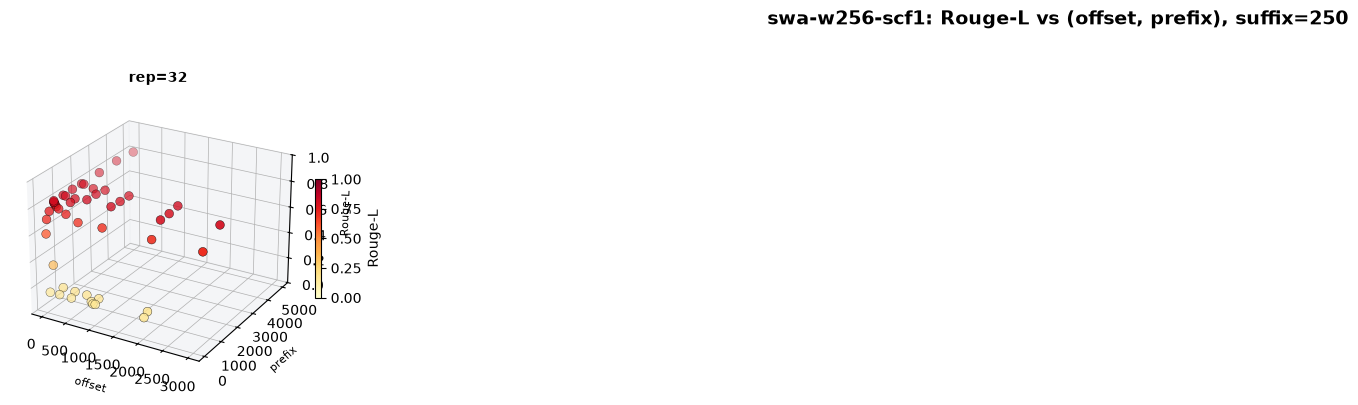

In [4]:
BACKEND = ['megatron', 'hf']
SUFFIX = 250

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 250, 500, 750, 900, 950, 1000, 2000, 3000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 1500, 2000, 3000, 4000, 5000]

surface_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, [SUFFIX], models=['swa-w256-scf1'],
    results_base=model_registry.MEM_RESULTS_DIR, backend=BACKEND,
)
REPS = next(iter(next(iter(surface_grid.values())).values())).repetitions

plot_offset_prefix_reps(surface_grid, 'swa-w256-scf1', REPS, suffix=SUFFIX)

## Offset x prefix surface, one repetition, with floor shadow + diagonal overlays

Single 3D surface (not faceted by rep this time) for one fixed repetition -- triangulated
over whatever (offset, prefix) points exist (`plot_trisurf`, still sparse, same caveat as
above), colored by Rouge-L, mesh edges visible via `edgecolor`. A flattened `tricontourf`
projected onto the floor plane gives the "shadow" contour look. `diagonal_starts` overlays
thick lines along fixed `offset + prefix = S` (the anti-diagonal disentangling sweep) directly
on the surface -- pass any suffix_start value(s) that have >= 2 points on this grid.


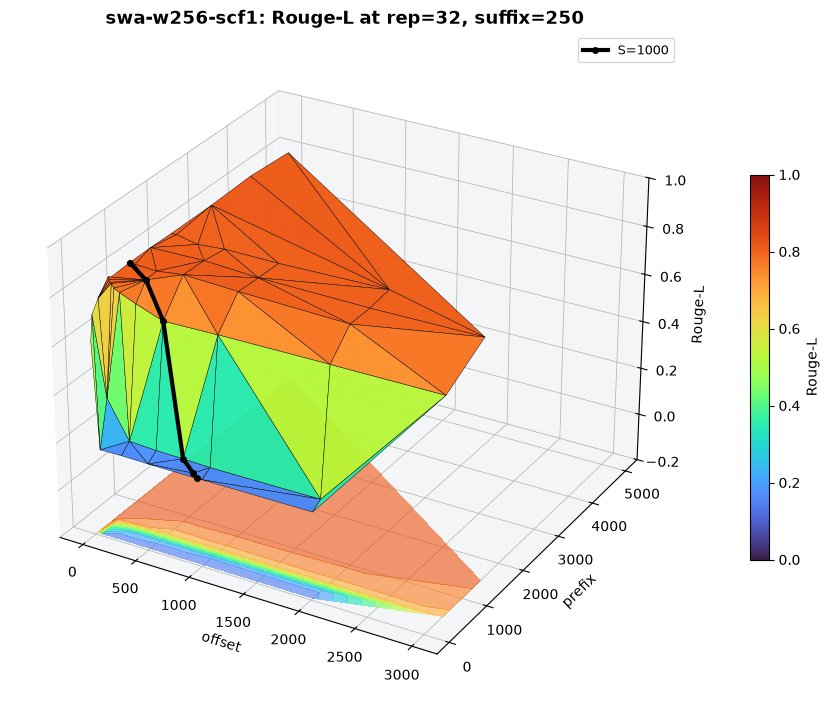

In [5]:
plot_offset_prefix_surface(surface_grid, 'swa-w256-scf1', rep=32, suffix=SUFFIX, diagonal_starts=[1000])


## Cloud + surface, auto-discovered points, hf-preferred

Instead of hand-listing offset/prefix values, scan every existing
`offset_O_prefix_P_suffix_250_greedy.pkl` on disk for a model (across the hf and megatron
backend folders) and use whatever's actually there. `backends=('hf', 'megatron')` order
matters for `load_mem_results_scores_grid`'s fallback -- hf tried first per point, megatron
only if hf doesn't have that exact point. One figure per model: cloud (scatter) next to
surface (`plot_trisurf` + floor shadow), same discovered points, same fixed rep.


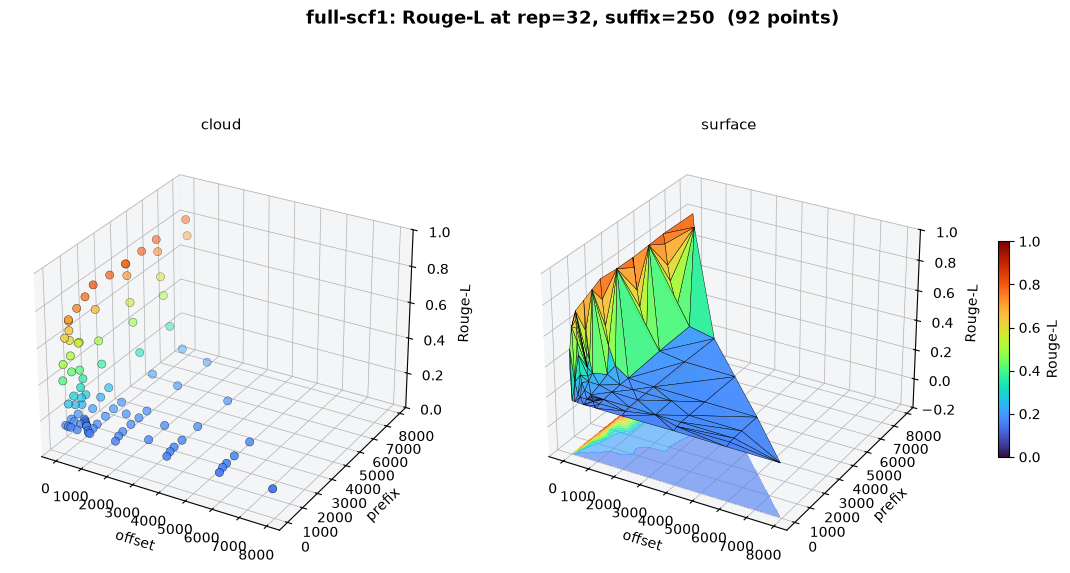

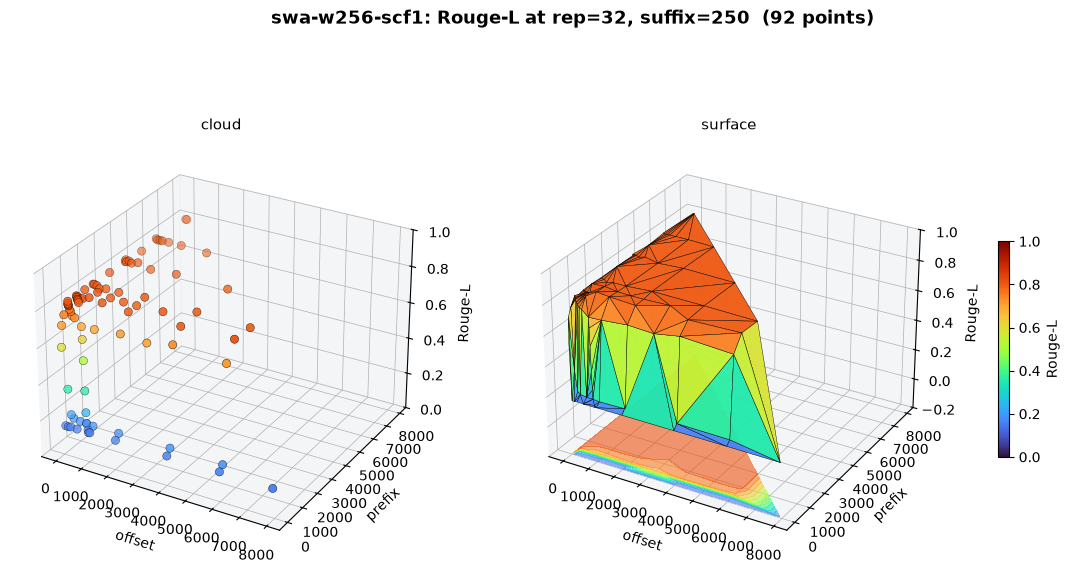

In [6]:
for model in ['full-scf1', 'swa-w256-scf1']:
    plot_cloud_and_surface(model, rep=32, suffix=250)


## Bars, not surface -- no interpolation at all

The interpolated surface above has a real problem: this point set (offset=0 row, prefix=500
column, S=1000 diagonal, 6x6 grid) spans a huge, irregular area, and `griddata`'s linear
interpolation fills the *entire convex hull* -- which means it draws straight-line
"surface" directly connecting things like `(0, 5000)` (saturated, ~1.0) to
`(3000, 500)` (plateaued, ~0.79) through regions with zero actual measurements. Bars fix
this completely: one bar per real point, height=metric, nothing fabricated in between.

Bar footprint is sized off the overall axis *range* (`bar_frac` x range), not the nearest-
neighbor gap -- this point set has pairs 1 unit apart (offset=0,1) and pairs 1000+ apart, so
gap-based sizing makes every bar an invisible needle (found this the hard way).


In [7]:
for model in ['full-scf1', 'swa-w256-scf1']:
    plot_cloud_bars_plotly(model, rep=32, suffix=250)


## 2D panel: offset x prefix, color = metric

With this few points, 3D is hard to read regardless of library -- flattening to 2D with
color as the third dimension is much clearer. `tricontourf` fills color between points
(Delaunay-triangulated, same linear-interpolation logic as `griddata`/`plot_trisurf`
elsewhere in this notebook -- stays inside the convex hull of the real points, no
fabricated color beyond it); the real points are scattered on top with a black edge at
their *exact* measured color, so it's clear what's real vs. interpolated. `cmap='turbo'`
(rainbow) throughout, matching the plotly figures above.


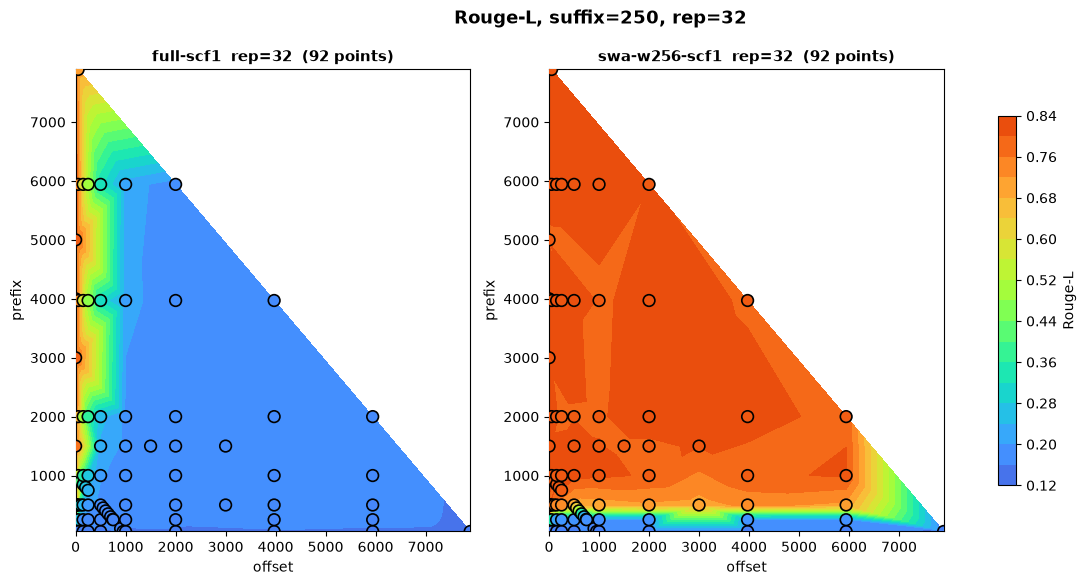

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model in zip(axes, ['full-scf1', 'swa-w256-scf1']):
    cf = plot_offset_prefix_panel_2d(model, rep=32, suffix=250, ax=ax)
fig.colorbar(cf, ax=axes, label='Rouge-L', shrink=0.8)
fig.suptitle('Rouge-L, suffix=250, rep=32', fontsize=13, weight='bold')
plt.show()


## Candidate grid for a denser 2D panel: existing vs. proposed new points

Designing a non-uniform (offset, prefix) grid for a future rep=32, full-scf1 + swa-w256-scf1
panel -- denser where the curves actually move, sparser where nothing changes:

- **offset**: dense in `[0, 250]` (both models change fast here, per the fixed-prefix=500
  offset sweep -- full-scf1 0.71->0.18, swa-w256 0.80->0.69), sparse above (both plateau by
  offset~500-750).
- **prefix**: `50` (below window), `250` (just below swa-w256's 256-token window, matches the
  round suffix/boundary values used elsewhere), `500`/`900` (inside/past its ramp `[250, 750]`,
  confirmed on the S=1000 diagonal at rep=32: 0.187@250 -> 0.796@750), `1500` (saturated
  anchor). Trimmed from an earlier 9-value version -- 90 new points/model was too much for a
  single-rep first pass.

7x5=35 combos, only 19 new per model (38 jobs total) after dedup against what's on disk.
`OFFSETS x PREFIXES` is a plain cartesian product -- offset doesn't affect generation cost,
so all 7 offsets at one prefix are effectively "free" repeats of that prefix's cost, only
the 5 distinct prefix values (x model) actually drive cost.

Green = already on disk (suffix=250, either backend), red X = still needed.


In [9]:
MAX_DOC_LENGTH, SUFFIX = 8192, 250
feasible_bound = MAX_DOC_LENGTH - SUFFIX

CANDIDATE_OFFSETS = [0, 50, 150, 250, 500, 1000, 2000, 3971, 5942, 7892]
CANDIDATE_PREFIXES = [50, 250, 500, 1000, 2000, 3971, 5942, 7892]

candidates = {(o, p) for o in CANDIDATE_OFFSETS for p in CANDIDATE_PREFIXES}

existing = set(discover_offset_prefix_points('full-scf1', 250))
have_pts = candidates & existing
new_pts = candidates - existing

new_feasible = {(o, p) for o, p in new_pts if o + p <= feasible_bound}
new_infeasible = new_pts - new_feasible

def _point_trace(pts, name, color, symbol):
    pts = sorted(pts)
    offsets, prefixes = [pt[0] for pt in pts], [pt[1] for pt in pts]
    totals = [o + p + SUFFIX for o, p in pts]
    return go.Scattergl(  # WebGL, not SVG -- SVG hover hit-testing breaks under PyCharm's
                        # container CSS transform (plotly/plotly.js#888)
        x=offsets, y=prefixes, mode='markers', name=f'{name} ({len(pts)})',
        marker=dict(color=color, symbol=symbol, size=11,
                   line=dict(width=1, color='black') if symbol == 'circle' else None),
        customdata=list(zip(offsets, prefixes, [SUFFIX] * len(pts), totals)),
        hovertemplate='offset: %{customdata[0]}<br>prefix: %{customdata[1]}<br>'
                      'suffix: %{customdata[2]}<br>total: %{customdata[3]}<extra></extra>',
    )

fig = go.Figure()
# a layout shape, not a trace, so it never interferes with point hover detection
fig.add_shape(type='path', path=f'M 0,0 L {feasible_bound},0 L 0,{feasible_bound} Z',
              fillcolor='rgba(144,238,144,0.3)', line=dict(width=0), layer='below')
fig.add_trace(go.Scatter(  # dummy point, just so the shape gets a legend entry
    x=[None], y=[None], mode='markers', marker=dict(size=10, symbol='square', color='rgba(144,238,144,0.6)'),
    name=f'feasible (offset+prefix+suffix<={MAX_DOC_LENGTH}, suffix={SUFFIX})',
))
if have_pts:
    fig.add_trace(_point_trace(have_pts, 'already have', 'green', 'circle'))
if new_feasible:
    fig.add_trace(_point_trace(new_feasible, 'new feasible', 'orange', 'x'))
if new_infeasible:
    fig.add_trace(_point_trace(new_infeasible, 'new infeasible', 'red', 'x'))

fig.update_layout(
    title=f'Candidate grid: {len(CANDIDATE_OFFSETS)}x{len(CANDIDATE_PREFIXES)} = {len(candidates)} combos, '
         f'{len(new_pts)} new per model',
    xaxis_title='offset', yaxis_title='prefix',
    hovermode='closest',
    width=950, height=650,
)
show_plotly(fig, iframe=True)

## Cloud + smoothed surface, plotly (interactive)

matplotlib's `plot_trisurf` on this sparse point cloud looks faceted -- it's raw
triangulation, no actual smoothing. This version interpolates onto a fine regular grid
with `scipy.interpolate.griddata` first (real smoothing, not just nicer rendering), then
draws it with plotly (`go.Surface`), which does proper continuous shading and is
interactive (rotate/zoom/hover) when run in a live notebook -- matplotlib 3D can't do either.

`interp='linear'` is the default and deliberately not `'cubic'`: cubic overshot past the
valid [0,1] Rouge-L range in testing (max 1.15) because our points are still sparse and
unevenly spread -- linear stays correctly bounded. `griddata` returns NaN outside the
convex hull of the actual points, so plotly leaves those cells as gaps rather than
fabricating a surface where nothing was measured -- raw points are also plotted as black
markers on top of the surface so it's clear which parts are real vs. interpolated.

Needs `pip install plotly` (and `kaleido` only if you want a static PNG export -- not
needed for the normal interactive Jupyter display).


In [ ]:
plot_offset_prefix_grid_3d(['full-scf1', 'swa-w4096-scf1', 'swa-w1024-scf1', 'swa-w256-scf1'], rep=32, suffix=250, ncols=2, points=sorted(candidates))

## Offset x prefix grid, 2D, one column per model x one row per repetition


Same editorial style as the 3D surface grid above (`COLORSCALE`, grid, fonts, single shared
colorbar) and the same griddata-interpolated + feasibility-masked extrapolation, but flattened
to 2D filled contours -- easier to read than 3D once the point cloud is this sparse (see the
"2D panel" section above). `models` picks the columns, `reps` picks the rows, so a single `reps`
value collapses to one row with every model side by side.


In [11]:
grid_2d_points = sorted({(o, p) for o, p in candidates if o + p <= feasible_bound})
plot_offset_prefix_grid_2d(['full-scf1', 'swa-w4096-scf1', 'swa-w1024-scf1', 'swa-w256-scf1', 'sink-scf1', 'gated-scf1'], reps=[1, 16, 32, 64, 128, 256], suffix=250, points=grid_2d_points, save_path="output/figures/memorization_prefix_offset_grid_panel.pdf")